ВИЗУАЛИЗАЦИЯ ПРИМЕРОВ С ЦВЕТОВЫМИ БОКСАМИ
Анализ 89 изображений...

ТАБЛИЦА РЕЗУЛЬТАТОВ АНАЛИЗА СИЗ:


,№,Изображение,Люди,Головы,Каски,Тела,Жилеты,Запястья,Перчатки,Статус
0,1,02044_jpg.rf.a2386346a93b5028dd03446d21c2cac2.jpg,5,0,5,1,5,0,4,[OK]
1,2,03253_jpg.rf.019a33cdac591e39e6a4241dad547978.jpg,0,0,3,1,0,0,0,[OK]
2,3,pos_2130_jpg.rf.98393edf3f88cd8a73aa326187f0b47b.jpg,3,3,0,1,2,1,1,[!]
3,4,00235_jpg.rf.0eba18329a6588585acf64bdad67629b.jpg,3,3,0,3,0,4,0,[!]
4,5,helmet_jacket_07369_jpg.rf.ffd34d6a9ee2e4a583ee649080f04b88.jpg,3,0,3,0,3,3,0,[!]
5,6,00504_jpg.rf.fc9a86cafd60a46cb9d7d8318a451546.jpg,8,1,5,3,5,3,1,[!]
6,7,pos_1349_jpg.rf.29b5b82ecd6b98f977c076750f05db50.jpg,3,0,3,0,3,2,0,[!]
7,8,1193310789_jpg.rf.31032f9f6517642696f05635e5417d3d.jpg,1,1,0,1,0,1,0,[!]
8,9,helmet_jacket_07590_jpg.rf.0083d5475d271648d1492c83f117efa9.jpg,2,0,2,0,2,0,3,[OK]
9,10,01279_jpg.rf.326b2dfad545b02614cc1707c9b98a1b.jpg,3,0,2,2,0,0,5,[!]



СТАТИСТИКА БЕЗОПАСНОСТИ:
Безопасные сцены: 3
Сцены с нарушениями: 12
Общее количество проанализированных изображений: 15

ВИЗУАЛИЗАЦИЯ ПРИМЕРОВ С НАРУШЕНИЯМИ:
Найдено примеров с нарушениями: 12

--- Пример нарушения 1: pos_2130_jpg.rf.98393edf3f88cd8a73aa326187f0b47b.jpg ---
Изображение сохранено: /content/ppe_detection/results/violation_1_pos_2130_jpg.rf.98393edf3f88cd8a73aa326187f0b47b.jpg.png


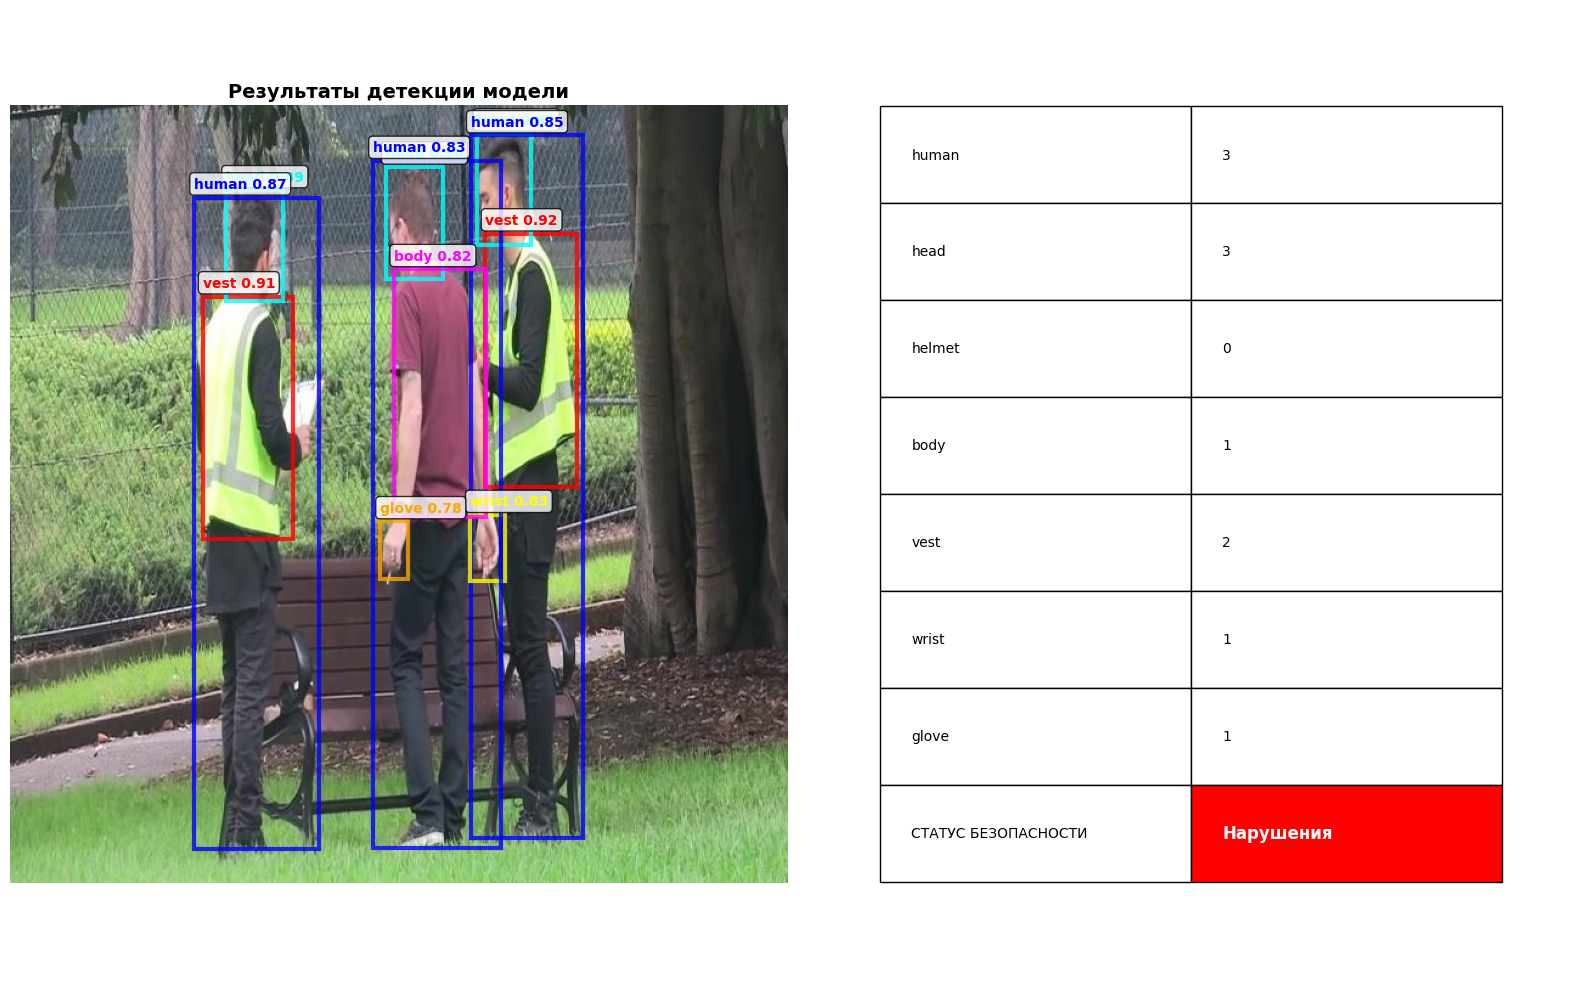


--- Пример нарушения 2: 00235_jpg.rf.0eba18329a6588585acf64bdad67629b.jpg ---
Изображение сохранено: /content/ppe_detection/results/violation_2_00235_jpg.rf.0eba18329a6588585acf64bdad67629b.jpg.png


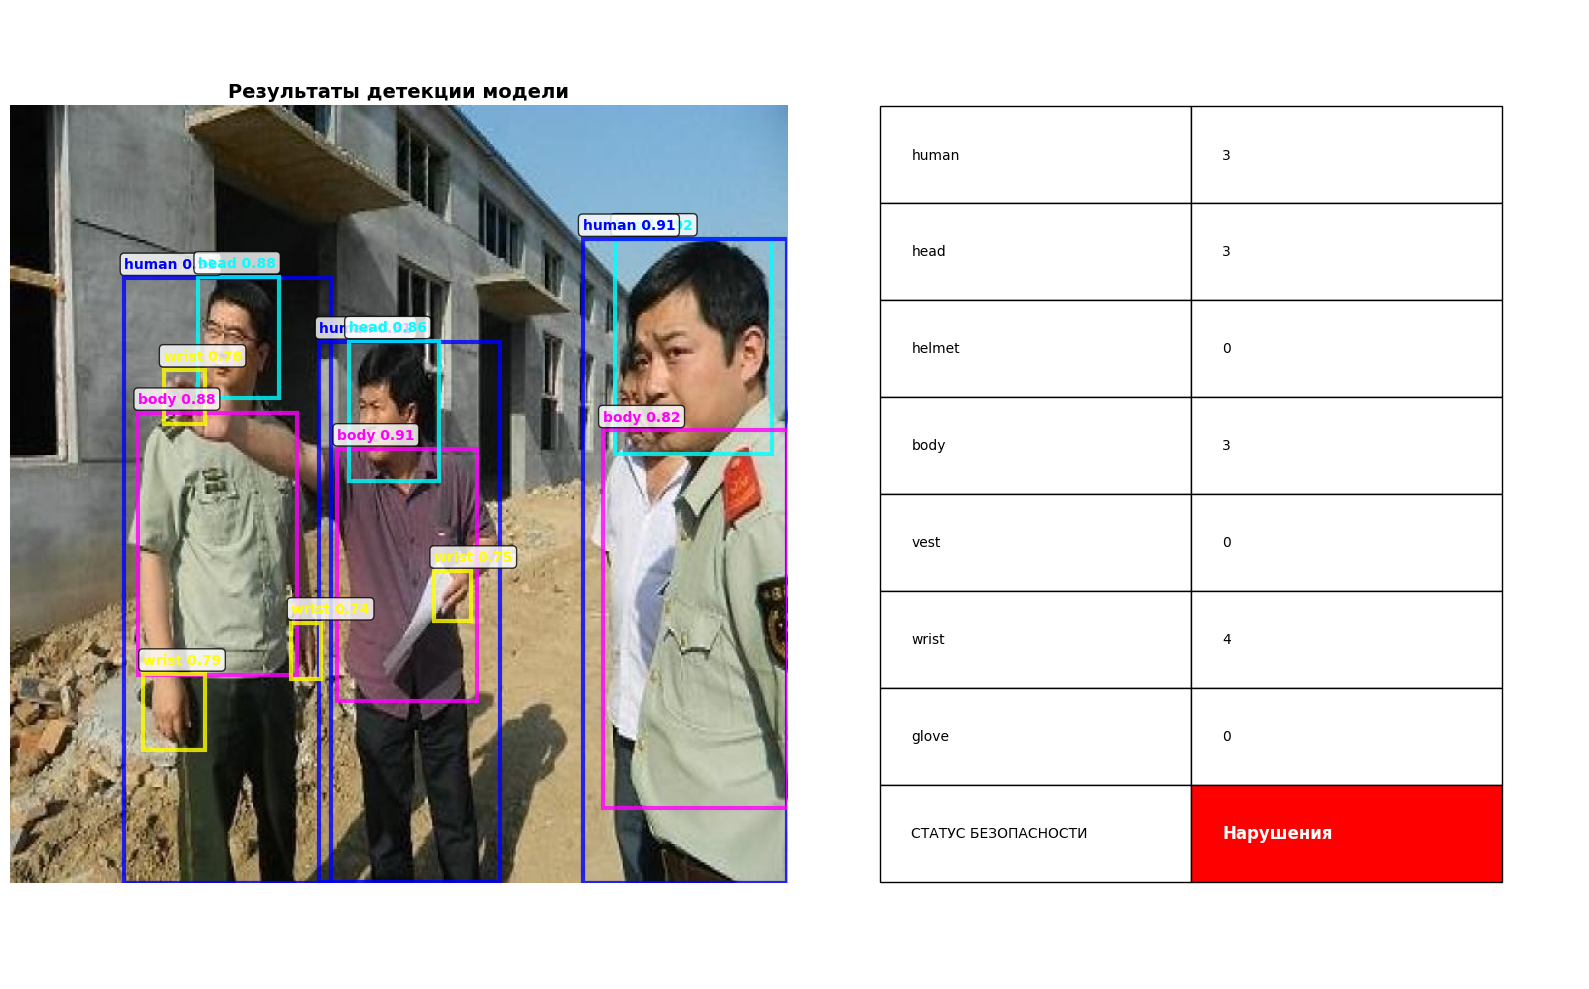


--- Пример нарушения 3: helmet_jacket_07369_jpg.rf.ffd34d6a9ee2e4a583ee649080f04b88.jpg ---
Изображение сохранено: /content/ppe_detection/results/violation_3_helmet_jacket_07369_jpg.rf.ffd34d6a9ee2e4a583ee649080f04b88.jpg.png


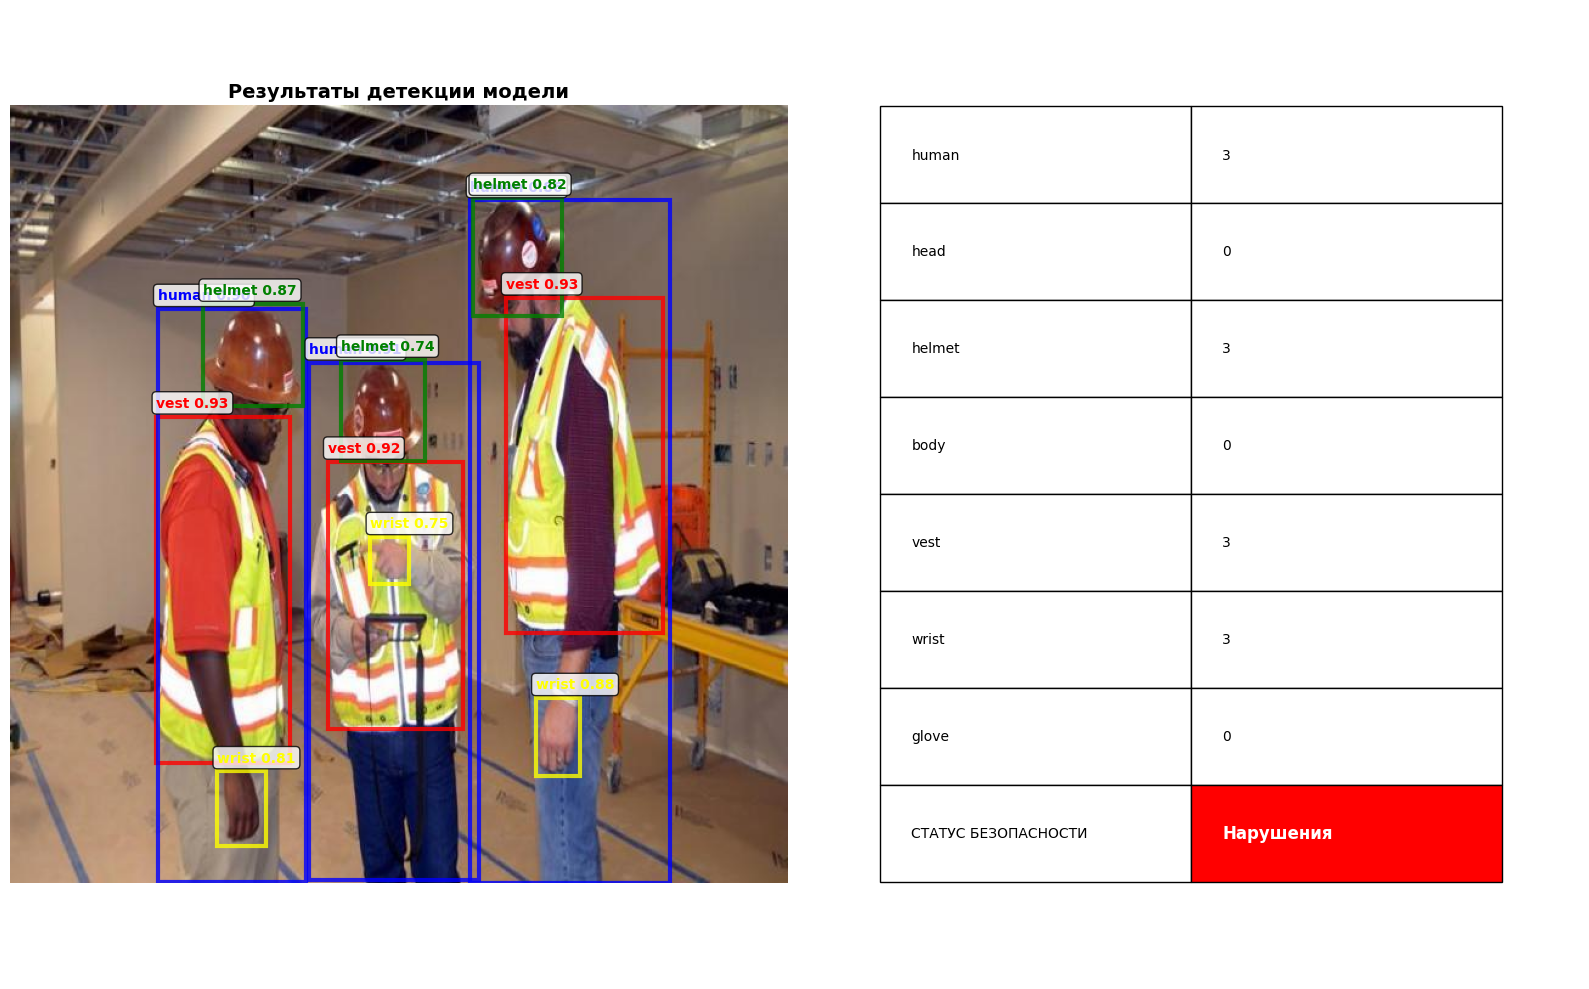


--- Пример нарушения 4: 00504_jpg.rf.fc9a86cafd60a46cb9d7d8318a451546.jpg ---
Изображение сохранено: /content/ppe_detection/results/violation_4_00504_jpg.rf.fc9a86cafd60a46cb9d7d8318a451546.jpg.png


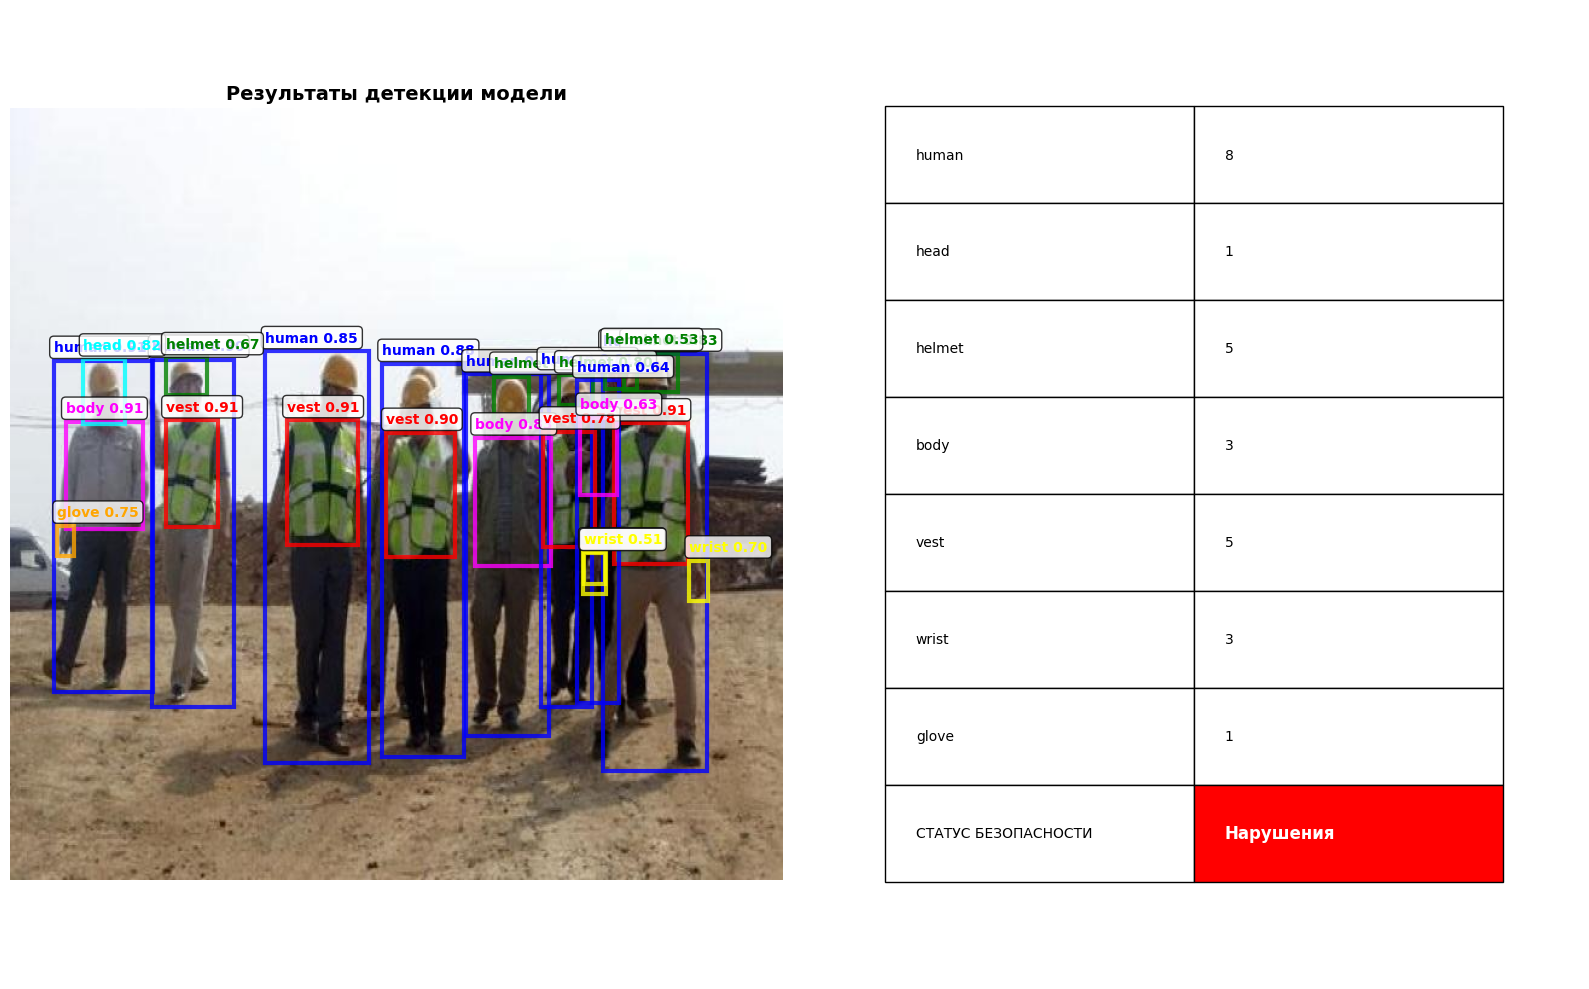


ВИЗУАЛИЗАЦИЯ БЕЗОПАСНЫХ ПРИМЕРОВ:
Найдено безопасных примеров: 3

--- Безопасный пример 1: 02044_jpg.rf.a2386346a93b5028dd03446d21c2cac2.jpg ---
Изображение сохранено: /content/ppe_detection/results/safe_1_02044_jpg.rf.a2386346a93b5028dd03446d21c2cac2.jpg.png


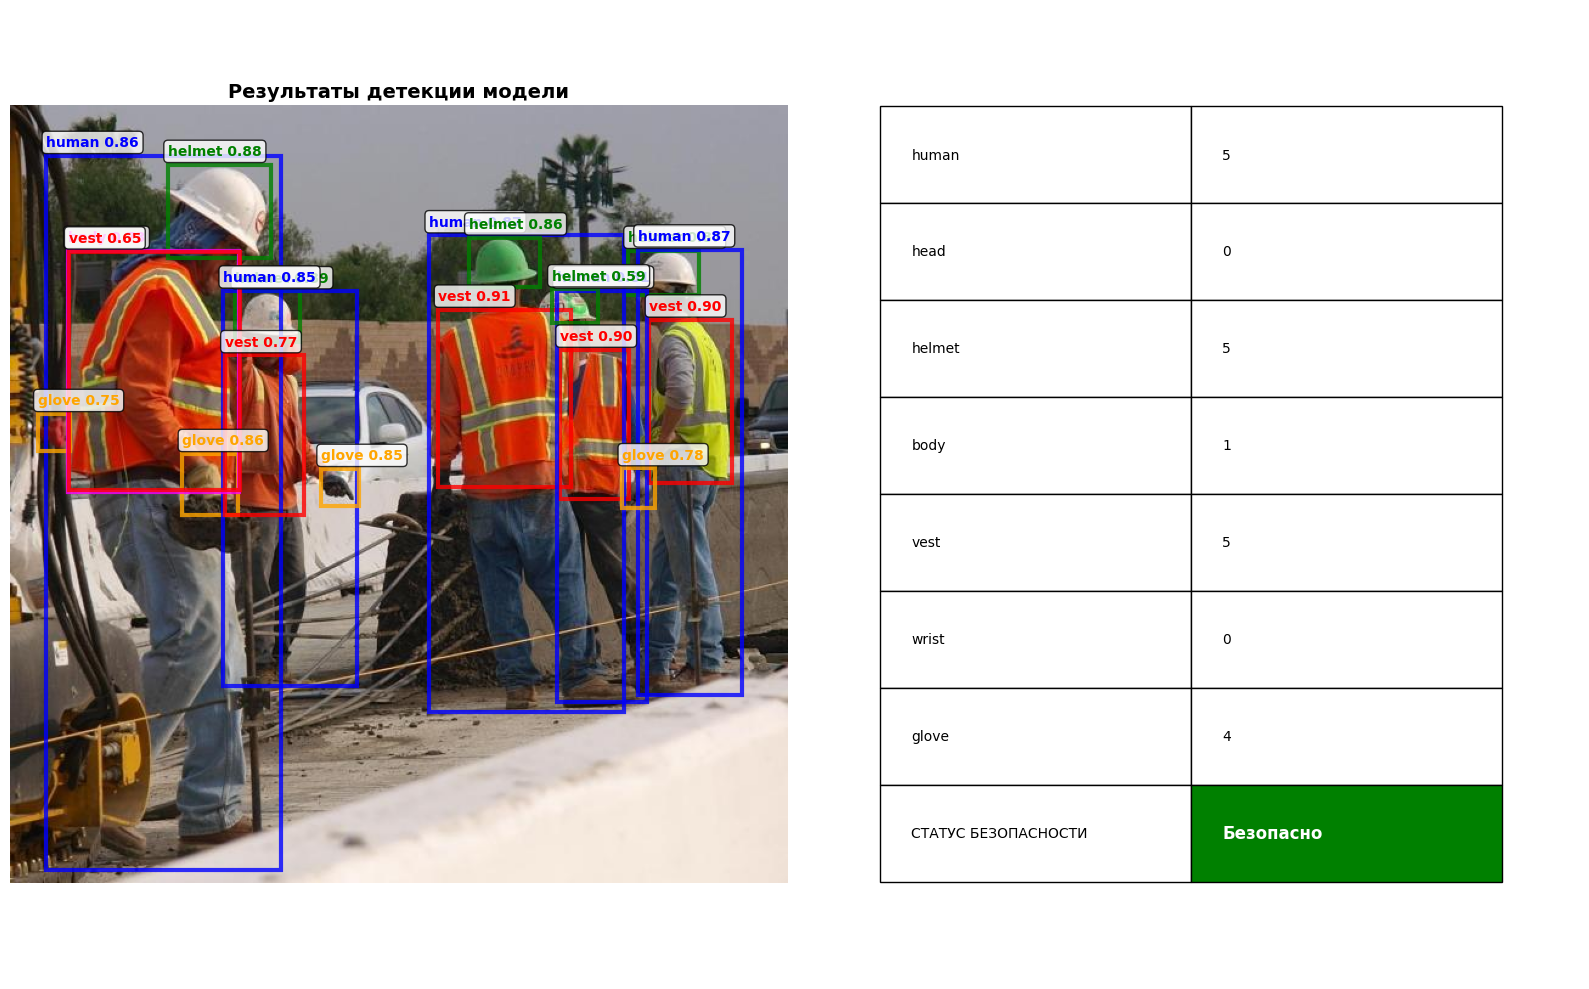


--- Безопасный пример 2: 03253_jpg.rf.019a33cdac591e39e6a4241dad547978.jpg ---
Изображение сохранено: /content/ppe_detection/results/safe_2_03253_jpg.rf.019a33cdac591e39e6a4241dad547978.jpg.png


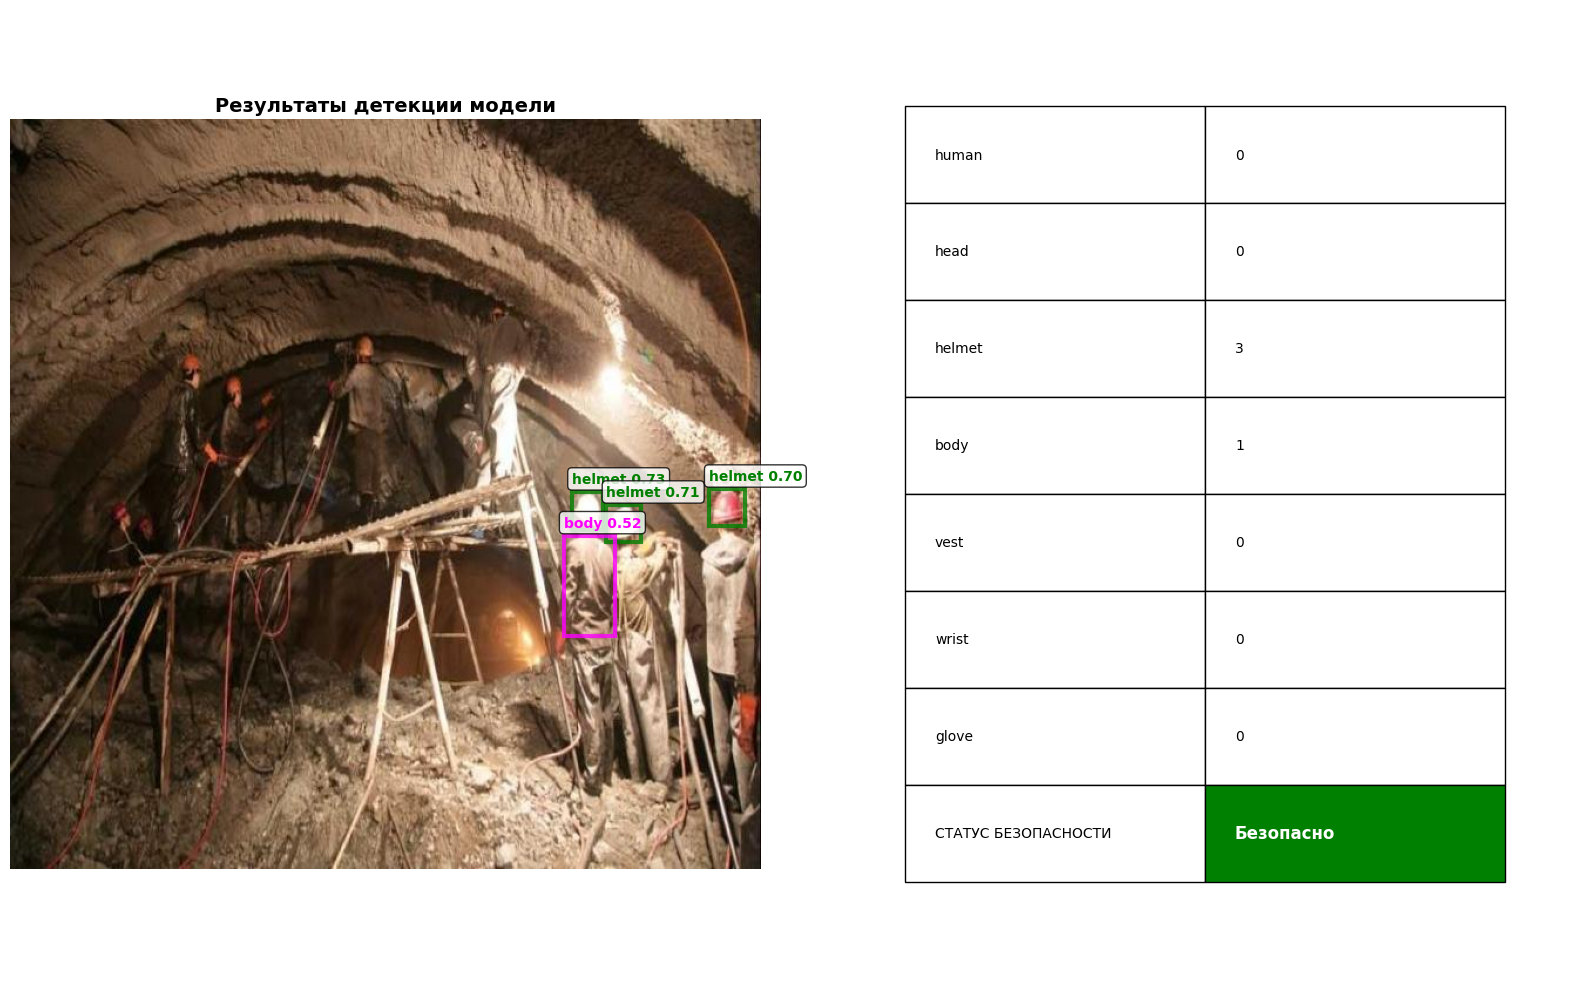


--- Безопасный пример 3: helmet_jacket_07590_jpg.rf.0083d5475d271648d1492c83f117efa9.jpg ---
Изображение сохранено: /content/ppe_detection/results/safe_3_helmet_jacket_07590_jpg.rf.0083d5475d271648d1492c83f117efa9.jpg.png


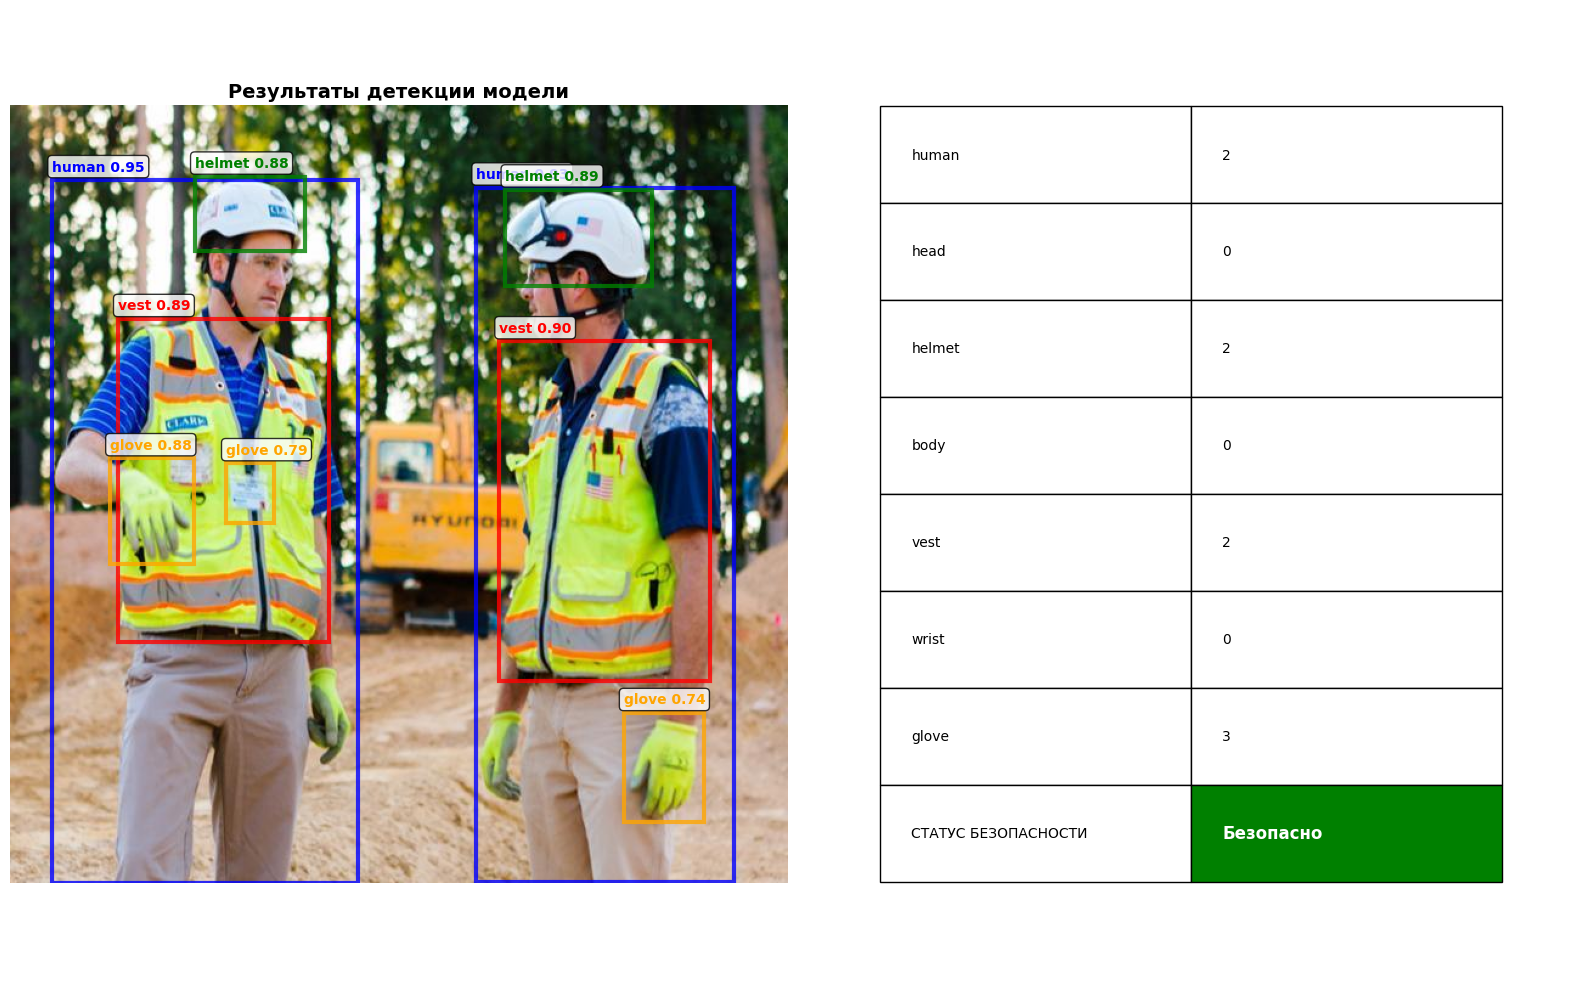

In [ ]:

def plot_detection_results(image_path, model_detections, analyzer, save_path=None):
    """Визуализация результатов детекции с улучшенным оформлением"""


    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_h, img_w = image.shape[:2]


    violations_report, _ = analyzer.analyze_violations(image_path, model)

    colors = {
        'human': 'blue',
        'head': 'cyan',
        'helmet': 'green',
        'body': 'magenta',
        'vest': 'red',
        'wrist': 'yellow',
        'glove': 'orange'
    }

    fig = plt.figure(figsize=(16, 10))

    ax1 = plt.subplot(1, 2, 1)
    ax1.imshow(image)
    ax1.set_title('Результаты детекции модели', fontsize=14, fontweight='bold')

    class_counts = {class_name: 0 for class_name in analyzer.class_names}
    for det in model_detections:
        class_name = det['class_name']
        if class_name in class_counts:
            class_counts[class_name] += 1

    for det in model_detections:
        x1, y1, x2, y2 = det['bbox']
        class_name = det['class_name']
        confidence = det['confidence']

        color = colors.get(class_name, 'gray')

        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                               linewidth=3, edgecolor=color, facecolor='none',
                               alpha=0.8)
        ax1.add_patch(rect)

        label_text = f"{class_name} {confidence:.2f}"
        ax1.text(x1, y1-8, label_text, fontsize=10,
                color=color, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    ax1.axis('off')

    ax2 = plt.subplot(1, 2, 2)
    ax2.axis('off')

    if violations_report:
        total_violations = (violations_report['no_helmet_violations'] +
                          violations_report['no_vest_violations'] +
                          violations_report['no_gloves_violations'])

        safety_status = "Безопасно" if total_violations == 0 else "Нарушения"
        safety_color = "green" if total_violations == 0 else "red"
    else:
        safety_status = "Нет данных"
        safety_color = "gray"

    table_data = []

    table_data.append(["human", class_counts.get('human', 0)])
    table_data.append(["head", class_counts.get('head', 0)])
    table_data.append(["helmet", class_counts.get('helmet', 0)])
    table_data.append(["body", class_counts.get('body', 0)])
    table_data.append(["vest", class_counts.get('vest', 0)])
    table_data.append(["wrist", class_counts.get('wrist', 0)])
    table_data.append(["glove", class_counts.get('glove', 0)])


    table_data.append(["СТАТУС БЕЗОПАСНОСТИ", safety_status])


    table = ax2.table(cellText=table_data,
                     cellLoc='left',
                     loc='center',
                     bbox=[0.1, 0.1, 0.8, 0.8])

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)

    for i, (key, value) in enumerate(table_data):
        if key == "СТАТУС БЕЗОПАСНОСТИ":
            cell = table[i, 1]
            cell.set_facecolor(safety_color)
            cell.set_text_props(color='white', weight='bold', fontsize=12)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Изображение сохранено: {save_path}")

    plt.show()

    return violations_report, class_counts

def generate_comprehensive_report_with_visualization(model, analyzer, num_examples=10):
    """Генерация комплексного отчета с визуализацией"""

    test_images_dir = os.path.join(dataset_dir, 'valid/images')
    image_files = [f for f in os.listdir(test_images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]


    results_data = []

    print(f"Анализ {len(image_files)} изображений...")

    for i, image_file in enumerate(image_files[:num_examples]):
        image_path = os.path.join(test_images_dir, image_file)

        try:
            violations_report, detections = analyzer.analyze_violations(image_path, model)

            if violations_report:

                class_counts = {class_name: 0 for class_name in analyzer.class_names}
                for det in detections:
                    class_name = det['class_name']
                    if class_name in class_counts:
                        class_counts[class_name] += 1


                total_violations = (violations_report['no_helmet_violations'] +
                                  violations_report['no_vest_violations'] +
                                  violations_report['no_gloves_violations'])

                if total_violations == 0:
                    safety_status = '[OK]'
                    safety_description = 'Безопасно'
                else:
                    safety_status = '[!]'
                    safety_description = 'Нарушения'

                row_data = {
                    '№': i + 1,
                    'Изображение': image_file,
                    'human': class_counts['human'],
                    'head': class_counts['head'],
                    'helmet': class_counts['helmet'],
                    'body': class_counts['body'],
                    'vest': class_counts['vest'],
                    'wrist': class_counts['wrist'],
                    'glove': class_counts['glove'],
                    'Безопасность_символ': safety_status,
                    'Безопасность_описание': safety_description,
                    'total_humans': violations_report['total_humans'],
                    'total_violations': total_violations
                }
                results_data.append(row_data)

        except Exception as e:
            print(f"Ошибка при анализе {image_file}: {e}")
            continue


    df = pd.DataFrame(results_data)

    if len(df) > 0:

        table_columns = ['№', 'Изображение', 'human', 'head', 'helmet', 'body', 'vest', 'wrist', 'glove', 'Безопасность_символ']

        print(f"\nТАБЛИЦА РЕЗУЛЬТАТОВ АНАЛИЗА СИЗ:")

        styled_df = df[table_columns]\
            .rename(columns={
                'human': 'Люди',
                'head': 'Головы',
                'helmet': 'Каски',
                'body': 'Тела',
                'vest': 'Жилеты',
                'wrist': 'Запястья',
                'glove': 'Перчатки',
                'Безопасность_символ': 'Статус'
            })\
            .style\
            .applymap(lambda x: 'background-color: #FFB6C1' if x == '[!]' else '', subset=['Статус'])\
            .applymap(lambda x: 'background-color: #90EE90' if x == '[OK]' else '', subset=['Статус'])\
            .set_properties(**{'text-align': 'center'})

        display(styled_df)


        safe_count = len(df[df['Безопасность_символ'] == '[OK]'])
        violation_count = len(df[df['Безопасность_символ'] == '[!]'])

        print(f"\nСТАТИСТИКА БЕЗОПАСНОСТИ:")
        print(f"Безопасные сцены: {safe_count}")
        print(f"Сцены с нарушениями: {violation_count}")
        print(f"Общее количество проанализированных изображений: {len(df)}")

        return df
    else:
        print("Нет данных для отображения")
        return None


def visualize_examples(model, analyzer, num_examples=8):
    """Визуализация примеров с цветовыми боксами"""

    test_images_dir = os.path.join(dataset_dir, 'valid/images')
    image_files = [f for f in os.listdir(test_images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    print("ВИЗУАЛИЗАЦИЯ ПРИМЕРОВ С ЦВЕТОВЫМИ БОКСАМИ")
    print("=" * 60)


    results_df = generate_comprehensive_report_with_visualization(model, analyzer, num_examples=15)

    if results_df is not None:

        violation_examples = results_df[results_df['Безопасность_символ'] == '[!]']

        safe_examples = results_df[results_df['Безопасность_символ'] == '[OK]']

        print(f"\nВИЗУАЛИЗАЦИЯ ПРИМЕРОВ С НАРУШЕНИЯМИ:")
        print(f"Найдено примеров с нарушениями: {len(violation_examples)}")

        for i, (_, row) in enumerate(violation_examples.head(4).iterrows()):
            image_path = os.path.join(test_images_dir, row['Изображение'])
            print(f"\n--- Пример нарушения {i+1}: {row['Изображение']} ---")
            violations_report, detections = analyzer.analyze_violations(image_path, model)
            save_path = os.path.join(RESULTS_DIR, f"violation_{i+1}_{row['Изображение']}.png")
            plot_detection_results(image_path, detections, analyzer, save_path)

        print(f"\nВИЗУАЛИЗАЦИЯ БЕЗОПАСНЫХ ПРИМЕРОВ:")
        print(f"Найдено безопасных примеров: {len(safe_examples)}")

        for i, (_, row) in enumerate(safe_examples.head(4).iterrows()):
            image_path = os.path.join(test_images_dir, row['Изображение'])
            print(f"\n--- Безопасный пример {i+1}: {row['Изображение']} ---")
            violations_report, detections = analyzer.analyze_violations(image_path, model)
            save_path = os.path.join(RESULTS_DIR, f"safe_{i+1}_{row['Изображение']}.png")
            plot_detection_results(image_path, detections, analyzer, save_path)


        if len(violation_examples) + len(safe_examples) < 6:
            print(f"\nДОПОЛНИТЕЛЬНЫЕ ПРИМЕРЫ:")
            additional_needed = 6 - (len(violation_examples) + len(safe_examples))
            for i in range(min(additional_needed, len(image_files))):
                image_path = os.path.join(test_images_dir, image_files[i])
                if image_files[i] not in results_df['Изображение'].values:
                    print(f"\n--- Дополнительный пример {i+1}: {image_files[i]} ---")
                    violations_report, detections = analyzer.analyze_violations(image_path, model)
                    if violations_report and violations_report['total_humans'] > 0:
                        save_path = os.path.join(RESULTS_DIR, f"additional_{i+1}_{image_files[i]}.png")
                        plot_detection_results(image_path, detections, analyzer, save_path)

if model:
    visualize_examples(model, analyzer, num_examples=8)